In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# EJI EDA

In [3]:
eji_data_raw = pd.read_excel('EJI_2024_United_States.xlsx', dtype={'GEOID': str})
eji_data_raw.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,1,1,20804,140000US01001020804,1001020804,1001020804,Autauga County,Alabama,AL,Census Tract 208.04; Autauga County; Alabama,...,0.0,0,0.0,156,2.8,26,0.5,0.0,-999,-999
1,1,3,10706,140000US01003010706,1003010706,1003010706,Baldwin County,Alabama,AL,Census Tract 107.06; Baldwin County; Alabama,...,0.0,0,0.0,77,1.8,0,0.0,0.0,-999,-999
2,1,3,11503,140000US01003011503,1003011503,1003011503,Baldwin County,Alabama,AL,Census Tract 115.03; Baldwin County; Alabama,...,0.0,0,0.0,232,2.8,0,0.0,0.0,-999,-999
3,1,3,11604,140000US01003011604,1003011604,1003011604,Baldwin County,Alabama,AL,Census Tract 116.04; Baldwin County; Alabama,...,0.0,0,0.0,34,1.2,33,1.1,0.0,-999,-999
4,1,5,950100,140000US01005950100,1005950100,1005950100,Barbour County,Alabama,AL,Census Tract 9501; Barbour County; Alabama,...,0.0,0,0.0,47,1.7,74,2.7,0.0,-999,-999


In [4]:
# E_* variables are estimates
# EPL_* variables are percentile ranks for estimates
# RPL_* variables are percentile ranks for domains and overall score
# Select E_ features and GEOID
eji_est_i = eji_data_raw.columns.str.startswith("E_")
eji_geoid_i = eji_data_raw.columns == "GEOID"
eji_rpl_i = eji_data_raw.columns.isin(["RPL_EJI_CBM", "RPL_HVM", "RPL_SVM", "RPL_EBM", "RPL_CBM"])
eji_keep_i = eji_est_i | eji_geoid_i | eji_rpl_i
eji_data = eji_data_raw.loc[:, eji_keep_i]
eji_data = eji_data.drop(columns=['E_TOTPOP', 'E_DAYPOP']) # drop population vars -- not needed for regression
# replace -999 values with NaN
eji_data = eji_data.replace(-999, np.nan)
eji_data.head()

,GEOID,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,...,E_SWND,E_TRND,RPL_CBM,E_AFAM,E_HISP,E_ASIAN,E_AIAN,E_NHPI,E_TWOMORE,E_OTHERRACE
0,1001020804,0.0033,27.3,18.3372,5.8,1.1,12.2,18.0,3.5,1.5,...,1.2050,0.0278,0.1443,19.5,3.8,0.8,0.0,0.0,2.8,0.5
1,1003010706,0.1261,15.6,14.6876,1.3,5.4,14.0,10.0,8.3,5.7,...,1.4408,0.0000,0.6241,8.1,0.9,4.7,0.0,0.0,1.8,0.0
2,1003011503,0.6773,23.0,37.8453,16.4,1.0,35.1,36.8,18.6,10.0,...,1.5392,0.0278,0.6418,11.8,7.1,1.2,0.0,0.0,2.8,0.0
3,1003011604,0.5041,4.7,27.8750,7.1,5.3,5.2,10.6,8.7,17.9,...,1.5392,0.0000,0.8545,0.0,2.4,0.1,0.0,0.0,1.2,1.1
4,1005950100,0.7367,54.0,37.6837,14.0,14.7,14.8,20.9,7.7,27.7,...,1.3610,0.1389,0.7603,48.1,0.1,1.5,0.0,0.0,1.7,2.7


In [5]:
eji_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85188 entries, 0 to 85187
Data columns (total 58 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GEOID        85188 non-null  object 
 1   RPL_EJI_CBM  82740 non-null  float64
 2   E_MINRTY     83014 non-null  float64
 3   E_POV200     82818 non-null  float64
 4   E_NOHSDP     82993 non-null  float64
 5   E_UNEMP      82868 non-null  float64
 6   E_RENTER     82759 non-null  float64
 7   E_HOUBDN     82759 non-null  float64
 8   E_UNINSUR    82871 non-null  float64
 9   E_NOINT      82759 non-null  float64
 10  E_AGE65      83014 non-null  float64
 11  E_AGE17      83014 non-null  float64
 12  E_DISABL     82871 non-null  float64
 13  E_LIMENG     83014 non-null  float64
 14  E_MOBILE     82788 non-null  float64
 15  E_GROUPQ     83014 non-null  float64
 16  RPL_SVM      82744 non-null  float64
 17  E_OZONE      83509 non-null  float64
 18  E_PM         83509 non-null  float64
 19  E_DS

In [6]:
eji_data.describe()

,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,E_AGE65,...,E_SWND,E_TRND,RPL_CBM,E_AFAM,E_HISP,E_ASIAN,E_AIAN,E_NHPI,E_TWOMORE,E_OTHERRACE
count,82740.000000,83014.000000,82818.000000,82993.000000,82868.000000,82759.000000,82759.000000,82871.000000,82759.000000,83014.000000,...,83480.000000,83509.000000,83509.000000,83014.000000,83014.000000,83014.000000,83014.000000,83014.000000,83014.000000,83014.000000
mean,0.499979,40.196917,30.521036,11.428628,5.637094,35.205523,26.477299,8.816740,12.366244,17.294555,...,2.881170,0.023107,0.499953,13.042137,17.557871,5.038912,0.615100,0.115474,3.408160,0.418594
std,0.288681,29.451741,17.736274,10.011650,4.612263,23.793045,12.479839,7.485913,9.358588,9.020339,...,2.540088,0.066321,0.288696,20.665778,21.910612,9.373665,4.267774,0.666819,3.065562,1.144239
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,14.800000,16.550100,4.300000,2.600000,16.300000,17.300000,3.600000,5.400000,11.700000,...,0.853975,0.000000,0.249600,0.800000,3.000000,0.100000,0.000000,0.000000,1.300000,0.000000
50%,0.500000,32.600000,27.882550,8.600000,4.600000,29.700000,24.300000,6.800000,10.400000,16.300000,...,1.879600,0.000000,0.499900,4.000000,8.500000,1.500000,0.000000,0.000000,2.700000,0.000000
75%,0.750000,62.700000,41.678025,15.400000,7.400000,50.200000,33.800000,11.900000,17.000000,21.300000,...,5.078200,0.027800,0.750000,15.000000,22.600000,5.400000,0.200000,0.000000,4.700000,0.400000
max,1.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,66.521400,2.972200,1.000000,100.000000,100.000000,100.000000,100.000000,44.900000,100.000000,33.200000


In [7]:
# check lengths of FIPS codes
eji_data['GEOID'].map(len).describe()

count    85188.000000
mean        10.816453
std          0.387117
min         10.000000
25%         11.000000
50%         11.000000
75%         11.000000
max         11.000000
Name: GEOID, dtype: float64

# CVI EDA

In [8]:
cvi_data_raw = pd.read_excel('Master CVI Dataset - Oct 2023.xlsx', sheet_name='Indicator Native Units', dtype={'FIPS Code': str})
cvi_data_raw.head()

,State,County,FIPS Code,Geographic Coordinates,Life Expectancy,Self-Reported Physical Health,Self-Reported Mental Health,"Drug Overdose Deaths per 100,000 People",Alcohol Abuse,Suicide Rates,...,Surface PM2.5,Snowfall,Standardized Precip Index,Total Precipitation,Coastal Flooding - Annualized Frequency,Riverine Flooding - Annualized Frequency,Sea Level Rise,Hurricane - Annualized Frequency,Tornado - Annualized Frequency,Winter Weather - Annualized Frequency
0,AL,Autauga,01001020100,"+32.4771112,-086.4903033",73.1,12.8,15.1,8.384539,14.4,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.003192,0.576606
1,AL,Autauga,01001020200,"+32.4757580,-086.4724678",76.9,15.1,17.4,8.384539,12.5,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.001502,0.576606
2,AL,Autauga,01001020300,"+32.4740243,-086.4597033",NaN,14.3,16.7,8.384539,13.9,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.002028,0.576606
3,AL,Autauga,01001020400,"+32.4710782,-086.4446805",75.4,12.1,13.2,8.384539,13.8,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.002296,0.576606
4,AL,Autauga,01001020500,"+32.4589157,-086.4218165",79.4,11.3,14.0,8.384539,14.7,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.003608,0.576606


In [9]:
cvi_data = cvi_data_raw.drop(columns=['State', 'County', 'Geographic Coordinates'])
cvi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73057 entries, 0 to 73056
Columns: 185 entries, FIPS Code to Winter Weather - Annualized Frequency
dtypes: float64(180), int64(4), object(1)
memory usage: 103.1+ MB


In [10]:
cvi_data.describe()

,Life Expectancy,Self-Reported Physical Health,Self-Reported Mental Health,"Drug Overdose Deaths per 100,000 People",Alcohol Abuse,Suicide Rates,Current Diabetes,Current Adult Asthma,Stroke,COPD,...,Surface PM2.5,Snowfall,Standardized Precip Index,Total Precipitation,Coastal Flooding - Annualized Frequency,Riverine Flooding - Annualized Frequency,Sea Level Rise,Hurricane - Annualized Frequency,Tornado - Annualized Frequency,Winter Weather - Annualized Frequency
count,67148.000000,72312.000000,72312.000000,73052.000000,72312.000000,73057.00000,72312.000000,72312.000000,72312.000000,72312.000000,...,73057.000000,73057.000000,73057.000000,73057.000000,32346.000000,72738.000000,6246.000000,55774.000000,7.273800e+04,72738.000000
mean,78.309247,13.402910,14.249008,21.382636,17.413504,16.06686,11.218213,9.897303,3.417185,7.312146,...,-1.683126,-0.094857,20.574030,4.489014,0.924114,1.920224,0.356169,0.073714,1.537551e-02,2.823343
std,3.991111,3.825288,3.408288,14.005072,3.506182,4.54535,3.751564,1.574177,1.254674,2.688635,...,0.908615,0.074745,19.091761,3.502181,1.622107,2.018753,0.110826,0.082457,5.768553e-02,2.862013
min,56.300000,3.800000,5.200000,0.000000,2.700000,8.00000,0.800000,5.400000,0.300000,1.100000,...,-3.295003,-0.872901,-27.011019,-8.362532,0.000000,0.000000,-0.183672,0.000000,1.203040e-08,0.000000
25%,75.800000,10.600000,11.800000,12.392145,15.200000,12.50000,8.700000,8.800000,2.600000,5.300000,...,-2.462579,-0.132577,2.727195,2.040365,0.000000,0.291667,0.312176,0.010000,3.611420e-04,0.494234
50%,78.500000,12.900000,13.900000,18.228471,17.200000,15.00000,10.700000,9.700000,3.200000,6.900000,...,-1.744406,-0.094397,26.775581,5.743941,0.002000,1.458333,0.371248,0.028889,1.162460e-03,2.306425
75%,81.000000,15.700000,16.300000,27.148953,19.400000,19.40000,13.100000,10.700000,4.000000,9.000000,...,-0.934564,-0.032568,36.375177,7.159938,1.512000,2.750000,0.425798,0.133423,5.148256e-03,4.118616
max,97.500000,41.000000,35.500000,126.728234,43.600000,29.30000,42.800000,20.600000,19.400000,26.700000,...,1.279230,0.017667,118.553233,30.761894,4.512000,12.666667,0.595340,0.443213,2.569549e+00,31.923502


In [11]:
# check lengths of FIPS codes
cvi_data['FIPS Code'].map(len).describe()

count    73057.0
mean        11.0
std          0.0
min         11.0
25%         11.0
50%         11.0
75%         11.0
max         11.0
Name: FIPS Code, dtype: float64

In [12]:
cvi_domain_data = pd.read_excel('Master CVI Dataset - Oct 2023.xlsx', sheet_name='Domain CVI Values', dtype={'FIPS Code': str})
cvi_domain_data.head()

,State,County,FIPS Code,Overall CVI Score,Baseline: All,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events
0,AL,Autauga,01001020100,0.576917,0.513116,0.587969,0.358101,0.724892,0.381501,0.661984,0.830940,0.649362,0.505651
1,AL,Autauga,01001020200,0.596915,0.556438,0.640211,0.465116,0.708693,0.411731,0.650884,0.834133,0.634943,0.483577
2,AL,Autauga,01001020300,0.602058,0.570042,0.628706,0.498134,0.703547,0.449783,0.644744,0.796535,0.650154,0.487544
3,AL,Autauga,01001020400,0.563530,0.485703,0.546426,0.325342,0.607588,0.463455,0.667300,0.840690,0.670403,0.490806
4,AL,Autauga,01001020500,0.567340,0.483049,0.437324,0.424390,0.615032,0.455449,0.679727,0.834594,0.715418,0.489171


In [13]:
cvi_domain_data.describe()

,Overall CVI Score,Baseline: All,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events
count,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000
mean,0.501478,0.487472,0.500027,0.512022,0.468132,0.469706,0.520152,0.526423,0.530083,0.503950
std,0.080485,0.116764,0.185760,0.156529,0.148585,0.154707,0.093799,0.184771,0.124200,0.134698
min,0.229956,0.146873,0.000000,0.000000,0.000000,0.000000,0.111595,0.000000,0.000000,0.000000
25%,0.443146,0.399269,0.359792,0.397814,0.360141,0.353895,0.456329,0.386836,0.443701,0.415277
50%,0.500803,0.485051,0.495574,0.511396,0.463155,0.466293,0.522597,0.520950,0.528096,0.502511
75%,0.559385,0.573500,0.641733,0.627161,0.573558,0.582392,0.587436,0.652526,0.615342,0.583994
max,0.751814,0.845725,1.000000,1.000000,1.000000,1.000000,0.826423,1.000000,1.000000,1.000000


In [14]:
cvi_domain_data['FIPS Code'].map(len).describe()

count    73057.0
mean        11.0
std          0.0
min         11.0
25%         11.0
50%         11.0
75%         11.0
max         11.0
Name: FIPS Code, dtype: float64

In [15]:
# merge CVI indicator and domain data
cvi_data = cvi_data.merge(cvi_domain_data.iloc[:,2:], on='FIPS Code', how='left')
cvi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73057 entries, 0 to 73056
Columns: 195 entries, FIPS Code to Climate Change: Extreme Events
dtypes: float64(190), int64(4), object(1)
memory usage: 108.7+ MB


# Combine EJI + CVI data

In [16]:
merged = eji_data.merge(cvi_data, left_on='GEOID', right_on='FIPS Code', how='inner').drop(columns=['FIPS Code'])

print('N rows merged:', len(merged))
print('Percent EJI tracts merged:', len(merged) / len(eji_data))
print('Percent CVI tracts merged:', len(merged) / len(cvi_data))

N rows merged: 49719
Percent EJI tracts merged: 0.5836385406395267
Percent CVI tracts merged: 0.6805508027978154


In [17]:
# count of EJI tracts not merged by state
eji_data_raw[~eji_data['GEOID'].isin(merged['GEOID'])]['STATEABBR'].value_counts()

STATEABBR
CA    9109
TX    3101
FL    1822
AZ    1765
GA    1536
CO    1447
AL    1436
NY    1008
NC     942
PR     940
CT     879
AR     823
WA     620
VA     560
OH     550
MO     517
LA     514
PA     507
MI     496
SC     429
MS     419
TN     409
KY     385
IN     375
NJ     346
OK     336
MN     332
OR     325
MA     294
IL     290
ID     263
WI     260
UT     235
HI     230
NM     217
MD     190
AK     177
NV     175
KS     159
IA     129
WV     122
NH     113
MT      96
ME      95
DE      83
GU      56
WY      55
DC      52
ND      51
SD      49
NE      40
VI      29
VT      28
MP      23
AS      18
RI      12
Name: count, dtype: int64

In [18]:
# count of CVI tracts not merged by state
cvi_data_raw[~cvi_data['FIPS Code'].isin(merged['GEOID'])]['State'].value_counts()

State
CA    8057
AZ    1526
TX    1482
CO    1249
AL    1181
FL     945
CT     833
GA     714
AR     686
NY     533
NC     477
OH     340
MI     338
WA     305
LA     283
VA     281
PA     280
MO     256
SC     215
MS     208
TN     205
KY     194
IN     193
NJ     181
OK     177
MN     168
AK     167
OR     165
MA     158
IL     150
HI     145
WI     141
MD     131
UT     107
ID     105
NM     104
KS     100
NV      83
WV      60
NH      59
IA      58
ME      52
MT      48
DE      42
SD      29
ND      28
WY      27
DC      25
VT      19
NE      19
RI       9
Name: count, dtype: int64

In [19]:
merged.head()

,GEOID,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,...,Overall CVI Score,Baseline: All,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events
0,12001000302,0.3834,41.8,36.4801,6.5,1.1,45.8,34.1,14.2,20.7,...,0.530455,0.548878,0.696164,0.539405,0.480197,0.479749,0.505890,0.617798,0.568056,0.331817
1,12001000500,0.6578,21.7,38.4186,0.2,4.0,55.9,37.5,13.4,12.1,...,0.458569,0.407843,0.511608,0.409151,0.320890,0.389724,0.526204,0.687192,0.589835,0.301585
2,12001000809,0.2877,40.8,70.0468,3.8,4.0,87.7,47.3,6.0,4.4,...,0.497224,0.489272,0.519381,0.618784,0.356717,0.462206,0.507826,0.645146,0.534879,0.343453
3,10003013611,0.0940,35.4,20.2682,2.2,3.8,39.9,22.2,1.9,5.0,...,0.493068,0.439486,0.445883,0.467883,0.425872,0.418305,0.564510,0.602067,0.483102,0.608363
4,10003015900,0.8550,45.6,26.2563,8.3,8.4,11.5,26.9,6.6,12.4,...,0.590535,0.609084,0.714513,0.609748,0.326695,0.785378,0.565804,0.629794,0.504792,0.562827


In [20]:
merged['Life Expectancy'].describe()

count    45963.000000
mean        77.993921
std          4.051056
min         56.300000
25%         75.500000
50%         78.200000
75%         80.700000
max         97.500000
Name: Life Expectancy, dtype: float64

In [21]:
merged['Life Expectancy'].isna().sum()

3756

In [22]:
eji_cvi_df = merged.dropna(subset=['Life Expectancy'])
len(eji_cvi_df)/len(merged)

0.9244554395703856

In [38]:
Y = df['Life Expectancy']
X = df.drop(columns=['GEOID', 'Life Expectancy', 'RPL_EJI_CBM', 'RPL_HVM', 'RPL_SVM', 'RPL_EBM', 'RPL_CBM']).drop(columns=cvi_domain_data.columns[3:].tolist())

In [34]:
Y = eji_cvi_df['Life Expectancy']
X = eji_cvi_df.drop(columns=['GEOID', 'Life Expectancy', 'RPL_EJI_CBM', 'RPL_HVM', 'RPL_SVM', 'RPL_EBM', 'RPL_CBM']).drop(columns=cvi_domain_data.columns[3:].tolist())
X.describe()

,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,E_AGE65,E_AGE17,...,Surface PM2.5,Snowfall,Standardized Precip Index,Total Precipitation,Coastal Flooding - Annualized Frequency,Riverine Flooding - Annualized Frequency,Sea Level Rise,Hurricane - Annualized Frequency,Tornado - Annualized Frequency,Winter Weather - Annualized Frequency
count,45786.000000,45786.000000,45786.000000,45786.000000,45785.000000,45785.000000,45786.000000,45785.000000,45786.000000,45786.000000,...,45963.000000,45963.000000,45963.000000,45963.000000,19847.000000,45963.000000,3727.000000,39284.000000,4.596300e+04,45963.000000
mean,36.830664,31.076300,11.091155,5.687042,33.683761,26.094343,8.752145,13.270696,17.834784,21.638625,...,-1.938787,-0.107681,26.129024,5.266531,1.029121,1.828346,0.378372,0.074084,1.689846e-02,3.337446
std,29.221011,17.220136,8.884730,4.516591,21.859081,11.650794,7.236802,8.951616,7.306434,6.154638,...,0.796925,0.070324,16.225727,3.041037,1.714436,1.756963,0.093996,0.081594,5.915920e-02,2.726256
min,0.000000,0.059200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-3.295003,-0.568684,-27.011019,-8.195518,0.000000,0.000000,0.130994,0.000000,9.628900e-07,0.000000
25%,12.200000,17.618950,4.700000,2.700000,16.400000,17.400000,3.600000,6.600000,13.000000,17.900000,...,-2.579343,-0.142849,16.904931,4.485799,0.000000,0.375000,0.323129,0.011968,5.135125e-04,1.400329
50%,27.600000,28.735250,8.700000,4.600000,28.900000,24.000000,6.700000,11.700000,17.100000,21.600000,...,-2.163597,-0.112205,30.828407,6.681999,0.002000,1.458333,0.412757,0.029920,1.292582e-03,3.047776
75%,57.000000,42.004950,15.000000,7.300000,47.500000,33.000000,11.800000,17.900000,21.600000,25.300000,...,-1.373893,-0.060418,37.070313,7.200877,2.049634,2.666667,0.427738,0.137634,5.772094e-03,4.530478
max,100.000000,100.000000,78.400000,50.900000,100.000000,81.700000,76.600000,79.300000,83.200000,67.600000,...,1.188802,0.000002,58.285493,10.315417,4.512000,8.708333,0.595340,0.443213,1.556178e+00,28.040339


Implement xGBoost with the above X and Y

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
import shap
import numpy as np
import pandas as pd

# -------------------------------
# Step 1: Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=7
)

# -------------------------------
# Step 2: Train XGBoost model
# -------------------------------
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    n_jobs=-1  # use all cores for faster training
)

xgb_model.fit(X_train, y_train)

# -------------------------------
# Step 3: Evaluate model
# -------------------------------
y_pred = xgb_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.3f}")



R² Score: 0.672
MAE: 1.784


R² = 0.672: Our model explains about 67% of variance in life expectancy across tracts. That’s pretty good for social + environmental data at tract level — indicates a useful model but not perfect.

MAE = 1.784: on average the model’s predictions are off by ~1.8 years of life expectancy. Whether that’s acceptable depends on domain/context (for public-health policy this can be meaningful but not enormous).

Received error with scientific notation data values. Convert to numbers.

In [43]:
# Check data types
print(X.dtypes)

# Check for non-numeric columns or unusual formats
print(X.head())


E_MINRTY                                    float64
E_POV200                                    float64
E_NOHSDP                                    float64
E_UNEMP                                     float64
E_RENTER                                    float64
                                             ...   
Riverine Flooding - Annualized Frequency    float64
Sea Level Rise                              float64
Hurricane - Annualized Frequency            float64
Tornado - Annualized Frequency              float64
Winter Weather - Annualized Frequency       float64
Length: 235, dtype: object
   E_MINRTY  E_POV200  E_NOHSDP  E_UNEMP  E_RENTER  E_HOUBDN  E_UNINSUR  \
0      41.8   36.4801       6.5      1.1      45.8      34.1       14.2   
1      21.7   38.4186       0.2      4.0      55.9      37.5       13.4   
2      40.8   70.0468       3.8      4.0      87.7      47.3        6.0   
3      35.4   20.2682       2.2      3.8      39.9      22.2        1.9   
4      45.6   26.2563     

In [44]:
for col in X.columns:
    if X[col].dtype == 'object':
        # Remove brackets and convert to float
        X[col] = X[col].str.replace(r'[\[\]]', '', regex=True).astype(float)


In [37]:
import pandas as pd
import numpy as np

# Our actual dataframe variable
df = eji_cvi_df

# Clean all columns: remove brackets, spaces, etc.
df = df.applymap(lambda x: str(x).replace('[', '').replace(']', '') if isinstance(x, str) else x)

# Convert all numeric-like columns to floats (ignoring errors)
df = df.apply(pd.to_numeric, errors='ignore')

# Optionally, print out which columns are still non-numeric
non_numeric = df.select_dtypes(include='object').columns
print("Still non-numeric columns:", list(non_numeric))


C:\Users\pgaut\AppData\Local\Temp\ipykernel_21900\3759443527.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).replace('[', '').replace(']', '') if isinstance(x, str) else x)
C:\Users\pgaut\AppData\Local\Temp\ipykernel_21900\3759443527.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


Still non-numeric columns: []


PermutationExplainer explainer: 45964it [16:19:19,  1.28s/it]                                  
C:\Users\pgaut\AppData\Local\Temp\ipykernel_21900\1416573128.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_numeric)


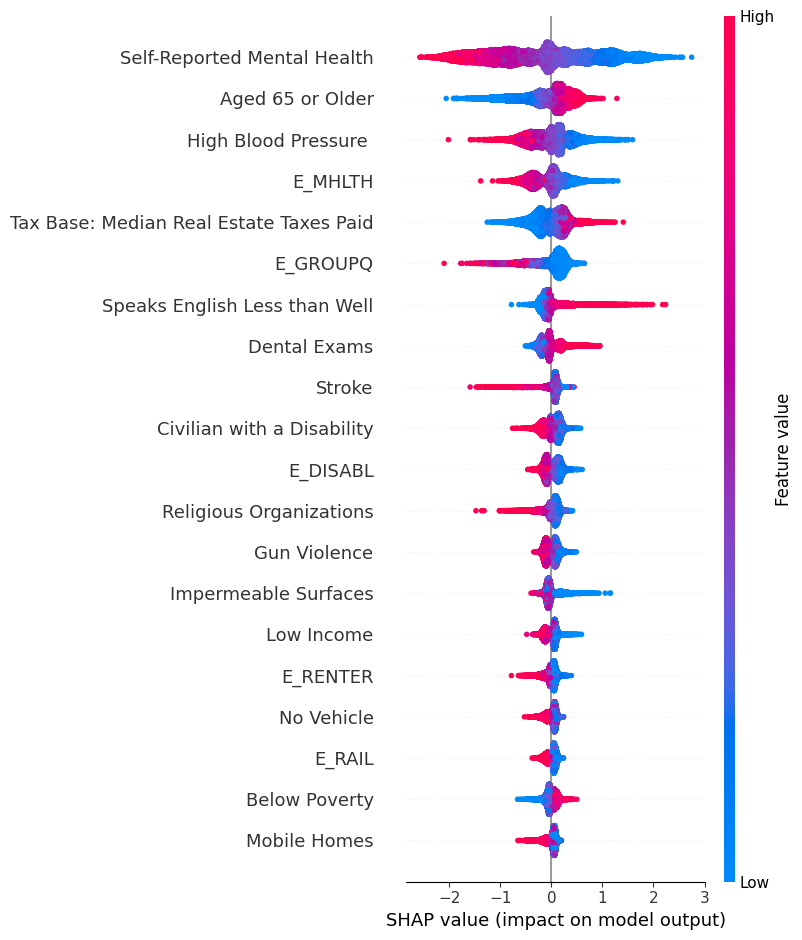

In [48]:
import shap

# Make sure the data is numeric
X_numeric = X.copy()

# Fit the model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    colsample_bytree=0.8
)
model.fit(X_train, y_train)

# SHAP Explainer
explainer = shap.Explainer(model.predict, X_numeric)  # note: pass model.predict, not model

# Calculate SHAP values
shap_values = explainer(X_numeric)

# Plot summary
shap.summary_plot(shap_values, X_numeric)



In [ ]:

# Mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

# Normalize SHAP weights
shap_importance['Weight'] = shap_importance['Mean_Abs_SHAP'] / shap_importance['Mean_Abs_SHAP'].sum()

# -------------------------------
# Step 5: Construct Geo Equity Index (GEI)
# -------------------------------
# Align features and weights
weighted_features = X_numeric[shap_importance['Feature']].mul(
    shap_importance.set_index('Feature')['Weight'], axis=1
)
df['Geo_Equity_Index'] = weighted_features.sum(axis=1)

# -------------------------------
# Step 6: Correlate GEI with Life Expectancy
# -------------------------------
corr = df[['Geo_Equity_Index', 'Life Expectancy']].corr().iloc[0, 1]
print(f"Correlation between GEI and Life Expectancy: {corr:.3f}")

# -------------------------------
# Step 7: SHAP summary plot (optional)
# -------------------------------
shap.summary_plot(shap_values, sample_for_shap)